In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
# 1. GitHub 저장소 클론
!git clone https://github.com/wangyz1999/timeVAE-pytorch.git

# 2. 해당 폴더로 이동 (매우 중요)
%cd timeVAE-pytorch

Cloning into 'timeVAE-pytorch'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (90/90), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 206 (delta 80), reused 77 (delta 77), pack-reused 116 (from 1)
Receiving objects: 100% (206/206), 20.25 MiB | 41.55 MiB/s, done.
Resolving deltas: 100% (118/118), done.
/kaggle/working/timeVAE-pytorch


In [34]:
import pandas as pd
import numpy as np
import os

def prepare_and_scale_data(file_path, save_name):
    df = pd.read_csv(file_path)
    
    # 1. 전처리 (Long format 변환)
    id_vars = ['Country Name', 'Series Code']
    year_cols = [c for c in df.columns if any(char.isdigit() for char in c)]
    df_long = df.melt(id_vars=id_vars, value_vars=year_cols, var_name='Year', value_name='Value').fillna(0)
    df_long = df_long.sort_values(by=['Country Name', 'Year', 'Series Code'])
    
    # 2. Reshape (Samples, Years, Features)
    n_samples, n_years, n_features = 214, len(year_cols), 12
    X = df_long['Value'].values.reshape(n_samples, n_years, n_features)
    
    # 3. Min-Max 스케일링 (0~1 사이로)
    # 나중에 업스케일링을 위해 feature별 min, max 저장
    x_min = X.min(axis=(0, 1), keepdims=True)
    x_max = X.max(axis=(0, 1), keepdims=True)
    X_scaled = (X - x_min) / (x_max - x_min + 1e-7)
    
    # 4. 저장 (학습용 데이터와 스케일링 정보 함께 저장)
    os.makedirs('/kaggle/working/timeVAE-pytorch/data', exist_ok=True)
    save_path = f'/kaggle/working/timeVAE-pytorch/data/{save_name}.npz'
    np.savez(save_path, data=X_scaled.astype(np.float32), x_min=x_min, x_max=x_max)
    
    print(f"✅ {save_name} 스케일링 완료: {X_scaled.shape}")
    return X_scaled

# 데이터 준비
csdi_scaled = prepare_and_scale_data('/kaggle/input/imputated/WorldBank_CSDI_Final.csv', 'my_csdi_data')
saits_scaled = prepare_and_scale_data('/kaggle/input/imputated/WorldBank_SAITS_Final.csv', 'my_saits_data')

✅ my_csdi_data 스케일링 완료: (214, 31, 12)
✅ my_saits_data 스케일링 완료: (214, 31, 12)


In [13]:
!find /kaggle/working/ -name "*.npz"

/kaggle/working/timeVAE-pytorch/data/energy_subsampled_train_perc_20.npz
/kaggle/working/timeVAE-pytorch/data/air_subsampled_train_perc_20.npz
/kaggle/working/timeVAE-pytorch/data/my_csdi_data.npz
/kaggle/working/timeVAE-pytorch/data/sine_subsampled_train_perc_20.npz
/kaggle/working/timeVAE-pytorch/data/stockv_subsampled_train_perc_20.npz
/kaggle/working/timeVAE-pytorch/data/air_subsampled_train_perc_2.npz
/kaggle/working/timeVAE-pytorch/data/stockv_subsampled_train_perc_100.npz
/kaggle/working/timeVAE-pytorch/data/stockv_subsampled_train_perc_10.npz
/kaggle/working/timeVAE-pytorch/data/sine_subsampled_train_perc_10.npz
/kaggle/working/timeVAE-pytorch/data/sine_subsampled_train_perc_2.npz
/kaggle/working/timeVAE-pytorch/data/sine_subsampled_train_perc_5.npz
/kaggle/working/timeVAE-pytorch/data/air_subsampled_train_perc_10.npz
/kaggle/working/timeVAE-pytorch/data/energy_subsampled_train_perc_100.npz
/kaggle/working/timeVAE-pytorch/data/stockv_subsampled_train_perc_5.npz
/kaggle/working/

In [35]:
import re

base_path = '/kaggle/working/timeVAE-pytorch'
file_path = os.path.join(base_path, 'src/vae_pipeline.py')
datasets = ["my_csdi_data", "my_saits_data"]

for ds in datasets:
    print(f"\n{'='*50}\n🔥 {ds} 학습 시작 (300 Epochs)\n{'='*50}")
    
    with open(file_path, 'r') as f:
        content = f.read()

    content = re.sub(r'dataset\s*=\s*".*?"', f'dataset = "{ds}"', content)
    content = re.sub(r'epochs\s*=\s*\d+', 'epochs = 300', content)
    content = re.sub(r'model_name\s*=\s*".*?"', 'model_name = "vae_conv"', content)

    with open(file_path, 'w') as f:
        f.write(content)
    
    %cd {base_path}
    !python src/vae_pipeline.py
    %cd /kaggle/working/


🔥 my_csdi_data 학습 시작 (300 Epochs)
/kaggle/working/timeVAE-pytorch
Epoch 1/300 | Total loss: 172.5992 | Recon loss: 57.3238 | KL loss: 0.6278
Epoch 2/300 | Total loss: 48.4101 | Recon loss: 15.8634 | KL loss: 0.8198
Epoch 3/300 | Total loss: 36.1533 | Recon loss: 12.0199 | KL loss: 0.0936
Epoch 4/300 | Total loss: 34.1474 | Recon loss: 11.3708 | KL loss: 0.0351
Epoch 5/300 | Total loss: 33.1099 | Recon loss: 11.0194 | KL loss: 0.0519
Epoch 6/300 | Total loss: 32.0801 | Recon loss: 10.6314 | KL loss: 0.1860
Epoch 7/300 | Total loss: 31.1834 | Recon loss: 10.1848 | KL loss: 0.6289
Epoch 8/300 | Total loss: 30.1921 | Recon loss: 9.6700 | KL loss: 1.1820
Epoch 9/300 | Total loss: 29.6284 | Recon loss: 9.4645 | KL loss: 1.2349
Epoch 10/300 | Total loss: 29.1068 | Recon loss: 9.2080 | KL loss: 1.4828
Epoch 11/300 | Total loss: 27.7957 | Recon loss: 8.8115 | KL loss: 1.3611
Epoch 12/300 | Total loss: 27.9024 | Recon loss: 8.7680 | KL loss: 1.5984
Epoch 13/300 | Total loss: 27.3652 | Recon los

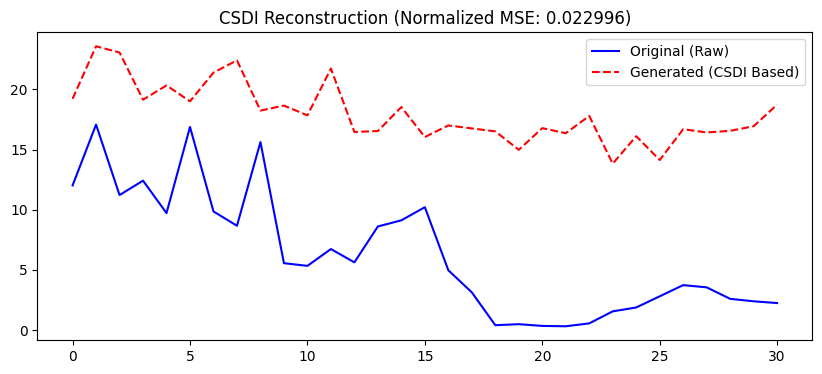

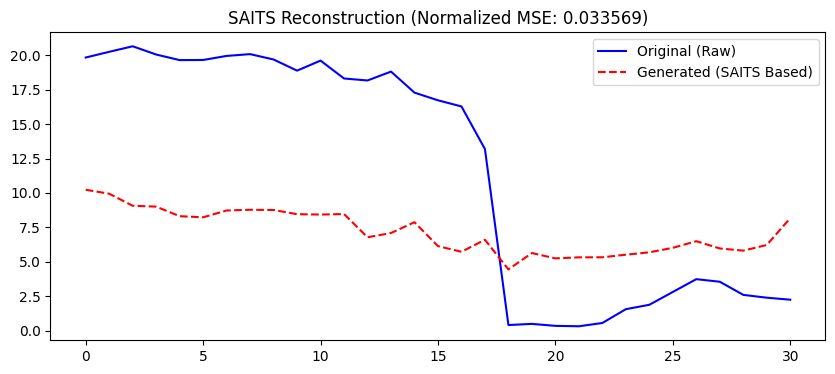


🏆 최종 성능 비교 (Normalized MSE):
CSDI: 0.022996
SAITS: 0.033569


In [42]:
import matplotlib.pyplot as plt

results = {}

for ds_name in ["CSDI", "SAITS"]:
    ds_key = f"my_{ds_name.lower()}_data"
    
    # 1. 데이터 로드 (원본 스케일링 정보 포함)
    ori_info = np.load(f'/kaggle/working/timeVAE-pytorch/data/{ds_key}.npz')
    gen_path = f'/kaggle/working/timeVAE-pytorch/outputs/gen_data/{ds_key}/vae_conv_{ds_key}_prior_samples.npz'
    
    if not os.path.exists(gen_path):
        print(f"❌ {ds_name} 결과 없음")
        continue
        
    ori_scaled = ori_info['data']
    x_min, x_max = ori_info['x_min'], ori_info['x_max']
    gen_scaled = np.load(gen_path)['data']
    
    # 2. 업스케일링 (Inverse Transform)
    # 원본 수치로 복원: Value * (max - min) + min
    ori_raw = ori_scaled[:len(gen_scaled)] * (x_max - x_min + 1e-7) + x_min
    gen_raw = gen_scaled * (x_max - x_min + 1e-7) + x_min
    
    # 3. MSE 계산 (정규화된 값으로 비교해야 성능 지표가 깔끔함)
    mse_norm = np.mean((ori_scaled[:len(gen_scaled)] - gen_scaled)**2)
    results[ds_name] = mse_norm
    
    # 4. 시각화 (원본 스케일 기준)
    plt.figure(figsize=(10, 4))
    plt.plot(ori_raw[0, :, 0], label='Original (Raw)', color='blue')
    plt.plot(gen_raw[0, :, 0], label=f'Generated ({ds_name} Based)', color='red', linestyle='--')
    plt.title(f"{ds_name} Reconstruction (Normalized MSE: {mse_norm:.6f})")
    plt.legend()
    plt.show()

print("\n🏆 최종 성능 비교 (Normalized MSE):")
for k, v in results.items():
    print(f"{k}: {v:.6f}")

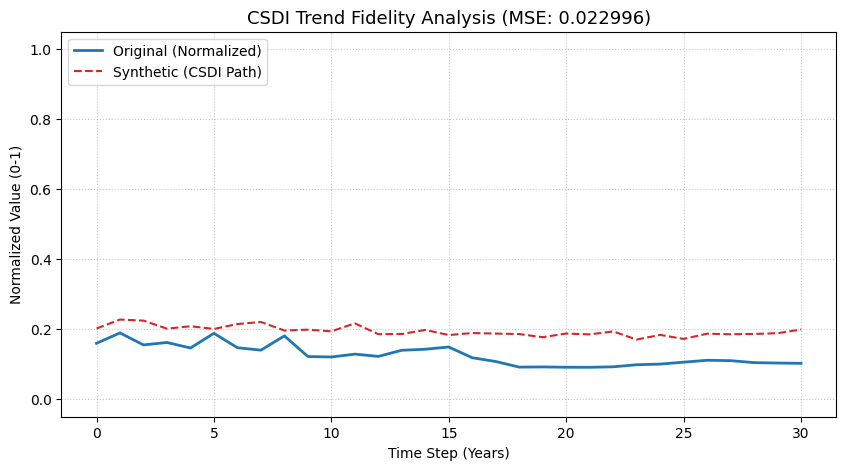

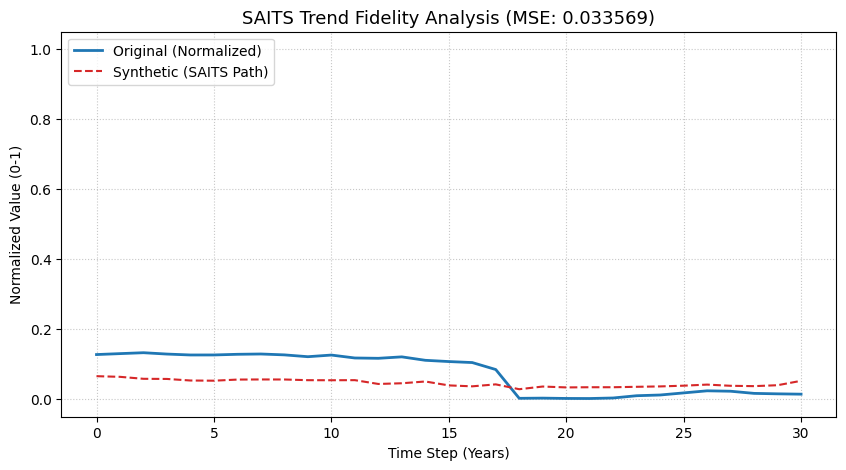

✅ 비교 완료: 0~1 스케일에서 두 모델의 패턴 일치도를 확인했습니다.


In [44]:
import matplotlib.pyplot as plt
import numpy as np

# MSE 수치와 그래프의 스케일을 0~1로 통일하여 비교
for ds_name in ["CSDI", "SAITS"]:
    ds_key = f"my_{ds_name.lower()}_data"
    
    # 1. 정규화된 데이터 로드
    info = np.load(f'/kaggle/working/timeVAE-pytorch/data/{ds_key}.npz')
    gen_scaled = np.load(f'/kaggle/working/timeVAE-pytorch/outputs/gen_data/{ds_key}/vae_conv_{ds_key}_prior_samples.npz')['data']
    ori_scaled = info['data'][:len(gen_scaled)]
    
    # 2. MSE 계산 (정규화 기준)
    mse_val = np.mean((ori_scaled - gen_scaled)**2)
    
    # 3. 시각화 (0~1 스케일 그대로 출력)
    plt.figure(figsize=(10, 5))
    
    # 첫 번째 샘플의 첫 번째 특징(Feature) 추세 비교
    plt.plot(ori_scaled[0, :, 0], label='Original (Normalized)', color='#1f77b4', linewidth=2)
    plt.plot(gen_scaled[0, :, 0], label=f'Synthetic ({ds_name} Path)', color='#d62728', linestyle='--')
    
    plt.ylim(-0.05, 1.05) # 0~1 범위를 명확히 보여줌
    plt.title(f"{ds_name} Trend Fidelity Analysis (MSE: {mse_val:.6f})", fontsize=13)
    plt.xlabel("Time Step (Years)")
    plt.ylabel("Normalized Value (0-1)")
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.show()

print(f"✅ 비교 완료: 0~1 스케일에서 두 모델의 패턴 일치도를 확인했습니다.")

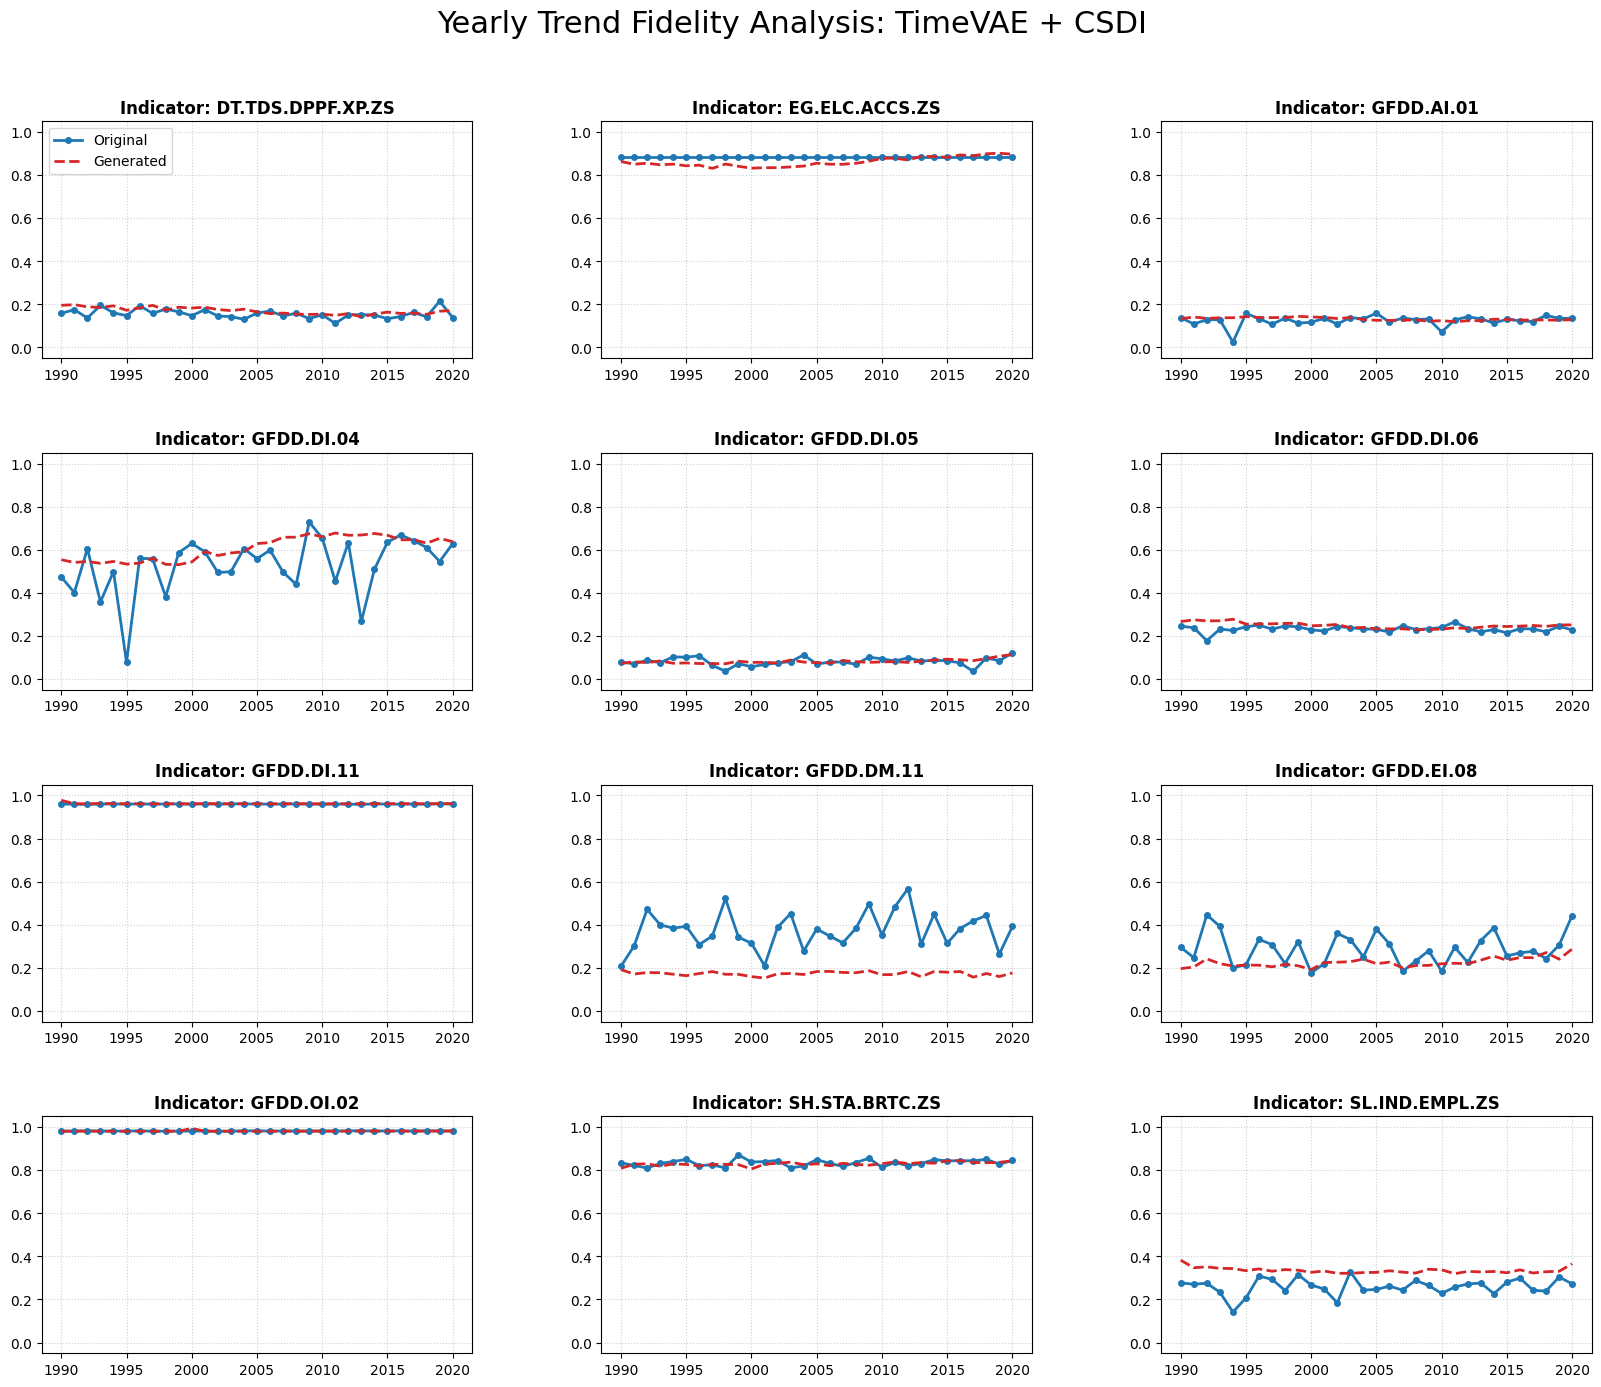

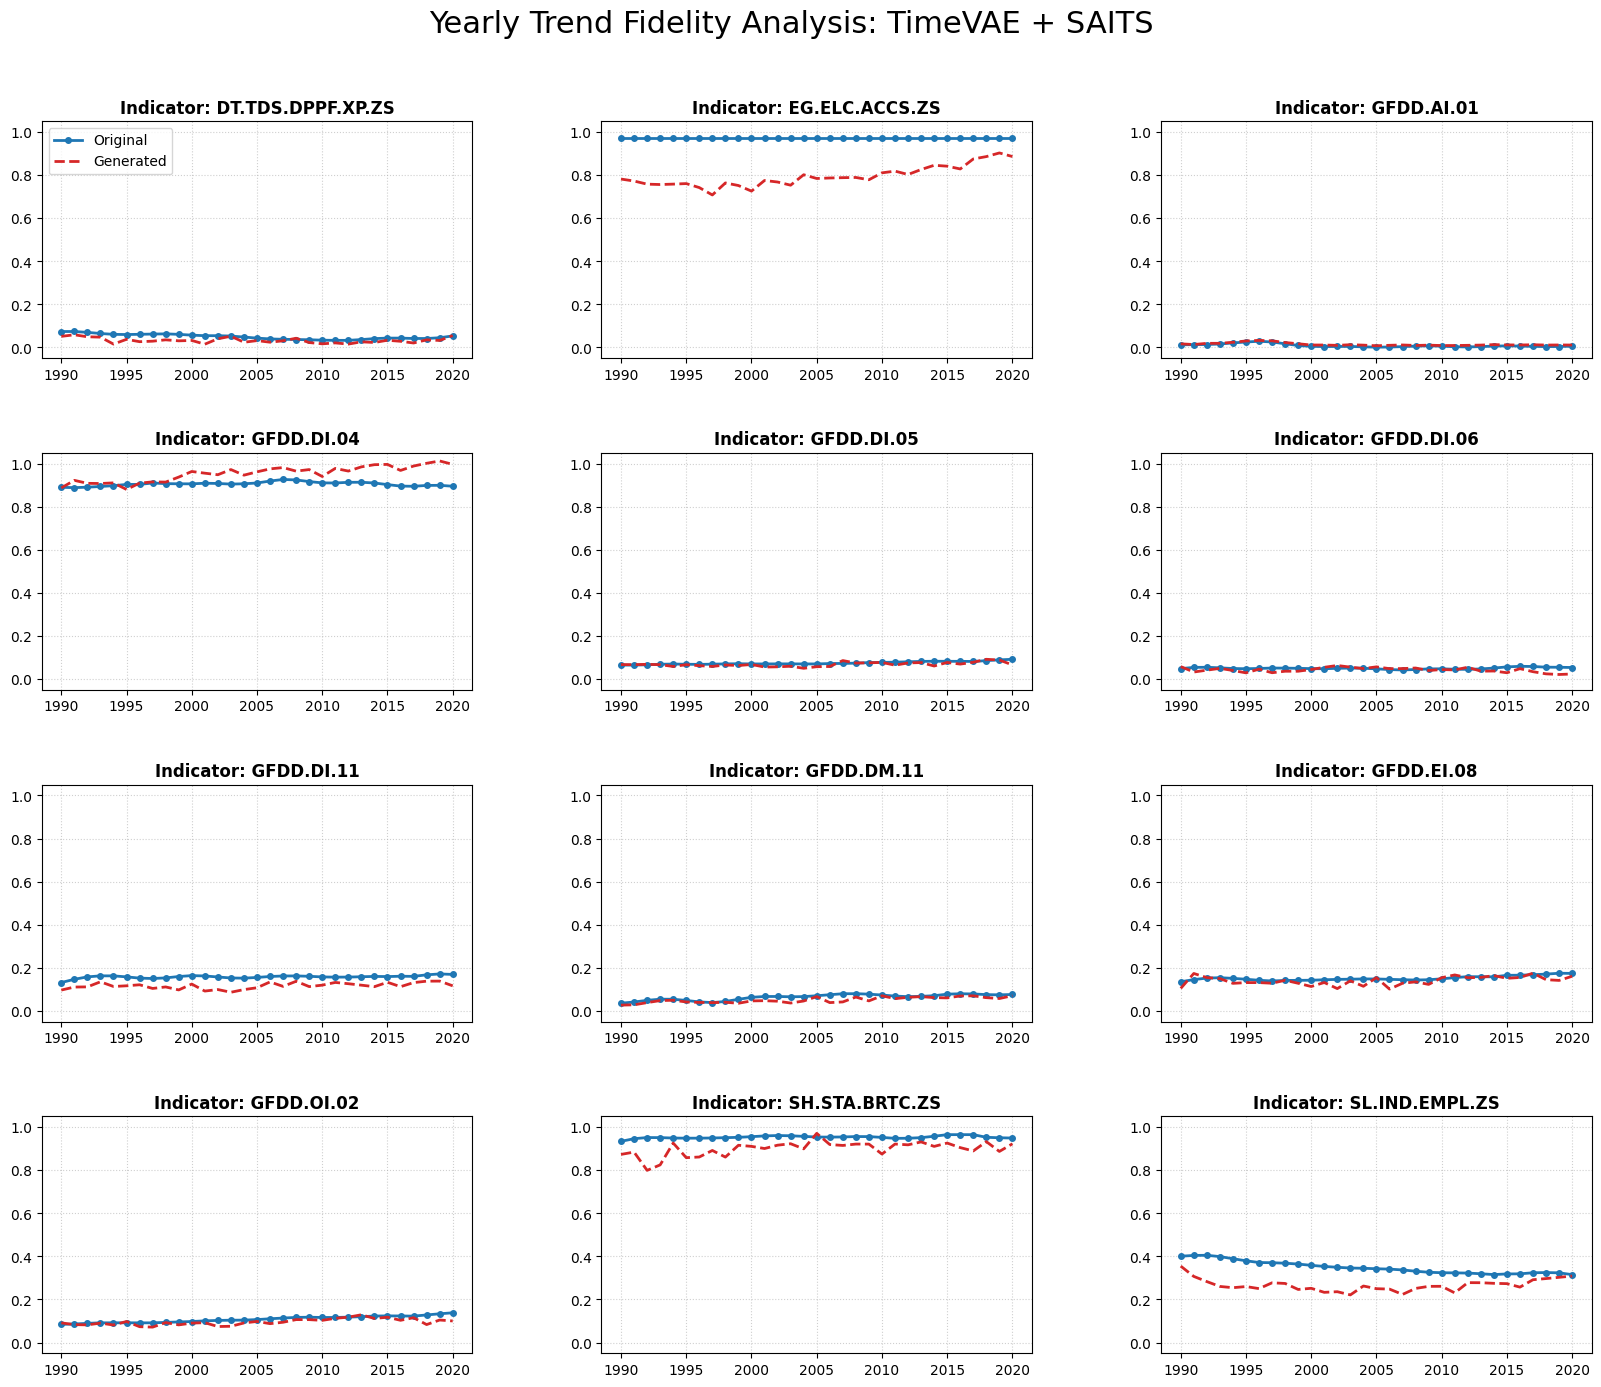

In [54]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 실제 연도 및 지표 이름 준비
raw_df = pd.read_csv('/kaggle/input/imputated/WorldBank_CSDI_Final.csv')
years = [c for c in raw_df.columns if any(char.isdigit() for char in c)]
real_series_names = raw_df['Series Code'].unique().tolist()[:12]

for ds_name in ["CSDI", "SAITS"]:
    ds_key = f"my_{ds_name.lower()}_data"
    info = np.load(f'/kaggle/working/timeVAE-pytorch/data/{ds_key}.npz')
    gen_scaled = np.load(f'/kaggle/working/timeVAE-pytorch/outputs/gen_data/{ds_key}/vae_conv_{ds_key}_prior_samples.npz')['data']
    ori_scaled = info['data'][:len(gen_scaled)]
    
    # 그래프 설정
    fig, axes = plt.subplots(4, 3, figsize=(20, 16))
    fig.subplots_adjust(hspace=0.4, wspace=0.3)
    axes = axes.flatten()

    for i in range(12):
        ax = axes[i]
        
        # 특정 샘플(첫 번째 국가)의 i번째 지표 연도별 흐름
        # 실제 데이터 패턴을 보여주기 위해 0번 샘플을 선택
        ax.plot(years, ori_scaled[3, :, i], label='Original', color='#1f77b4', linewidth=2, marker='o', markersize=4)
        ax.plot(years, gen_scaled[3, :, i], label='Generated', color='#d62728', linestyle='--', linewidth=2)
        
        ax.set_title(f"Indicator: {real_series_names[i]}", fontsize=12, fontweight='bold')
        ax.set_xticks(years[::5]) # 5년 단위로 x축 표시
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, linestyle=':', alpha=0.6)
        
        if i == 0:
            ax.legend(loc='upper left')

    plt.suptitle(f"Yearly Trend Fidelity Analysis: TimeVAE + {ds_name}", fontsize=22, y=0.95)
    plt.show()

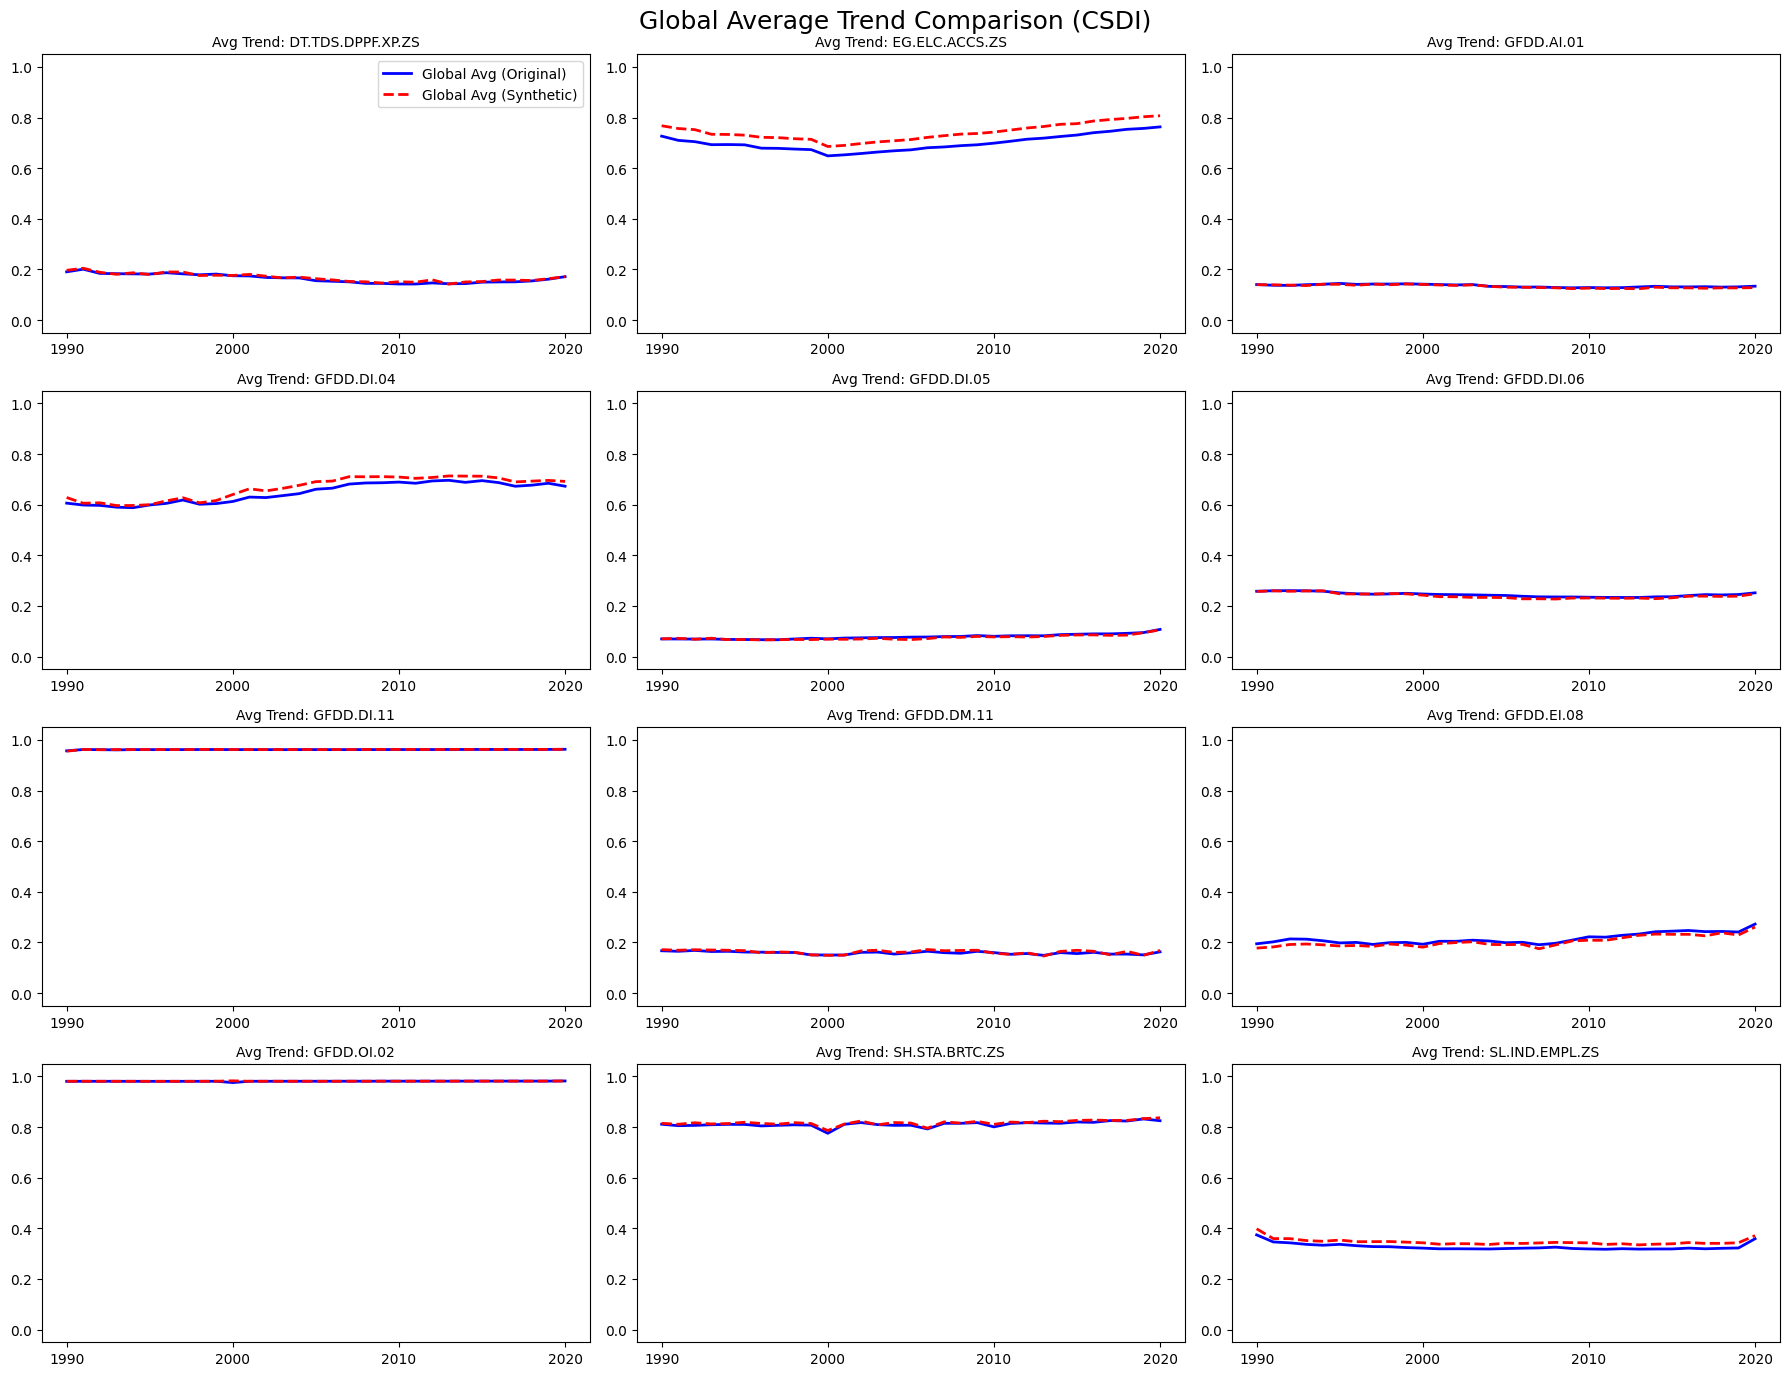

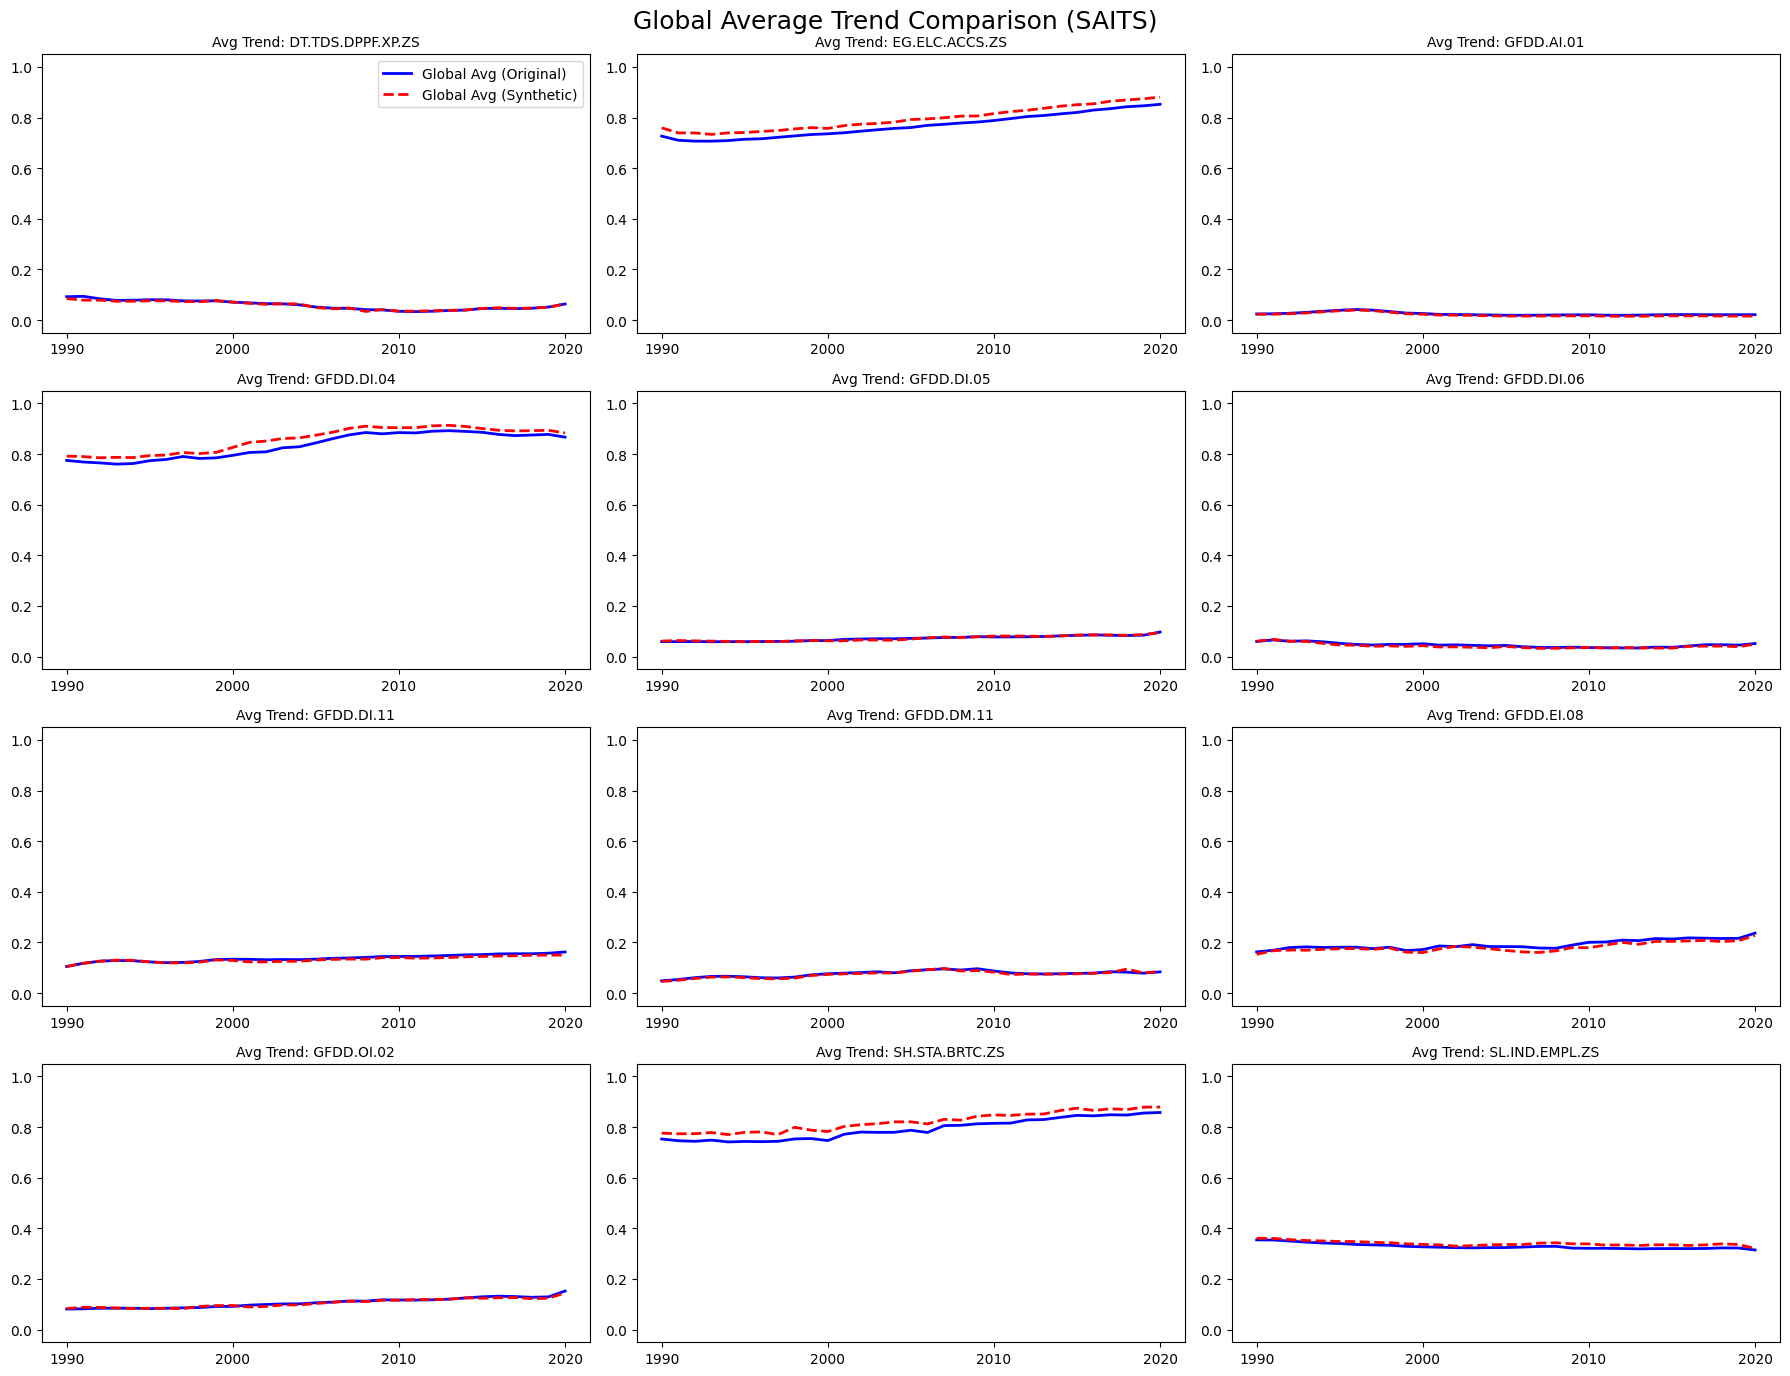

In [55]:
import matplotlib.pyplot as plt
import numpy as np

for ds_name in ["CSDI", "SAITS"]:
    ds_key = f"my_{ds_name.lower()}_data"
    info = np.load(f'/kaggle/working/timeVAE-pytorch/data/{ds_key}.npz')
    gen_scaled = np.load(f'/kaggle/working/timeVAE-pytorch/outputs/gen_data/{ds_key}/vae_conv_{ds_key}_prior_samples.npz')['data']
    ori_scaled = info['data'][:len(gen_scaled)]
    
    # [국가, 연도, 지표] 구조에서 '국가(axis=0)' 방향으로 평균 계산
    # 결과는 (연도, 지표) 형태가 됨
    ori_avg = np.mean(ori_scaled, axis=0)
    gen_avg = np.mean(gen_scaled, axis=0)
    
    fig, axes = plt.subplots(4, 3, figsize=(18, 14))
    axes = axes.flatten()
    
    for i in range(12):
        ax = axes[i]
        # 전 국가 평균값 플로팅
        ax.plot(years, ori_avg[:, i], label='Global Avg (Original)', color='blue', linewidth=2)
        ax.plot(years, gen_avg[:, i], label='Global Avg (Synthetic)', color='red', linestyle='--', linewidth=2)
        
        ax.set_title(f"Avg Trend: {real_series_names[i]}", fontsize=10)
        ax.set_ylim(-0.05, 1.05)
        ax.set_xticks(years[::10]) # 10년 단위 표시
        if i == 0: ax.legend()

    plt.suptitle(f"Global Average Trend Comparison ({ds_name})", fontsize=18, y=0.98)
    plt.tight_layout()
    plt.show()

📂 [지표별 실제 명칭 기준 MSE 상세 비교]


,CSDI,SAITS
DT.TDS.DPPF.XP.ZS,0.004076,0.002523
EG.ELC.ACCS.ZS,0.137383,0.158189
GFDD.AI.01,0.002403,0.001439
GFDD.DI.04,0.035257,0.050896
GFDD.DI.05,0.005167,0.004571
GFDD.DI.06,0.004377,0.004650
GFDD.DI.11,0.000242,0.013019
GFDD.DM.11,0.015218,0.004991
GFDD.EI.08,0.031253,0.022493
GFDD.OI.02,0.000175,0.011092


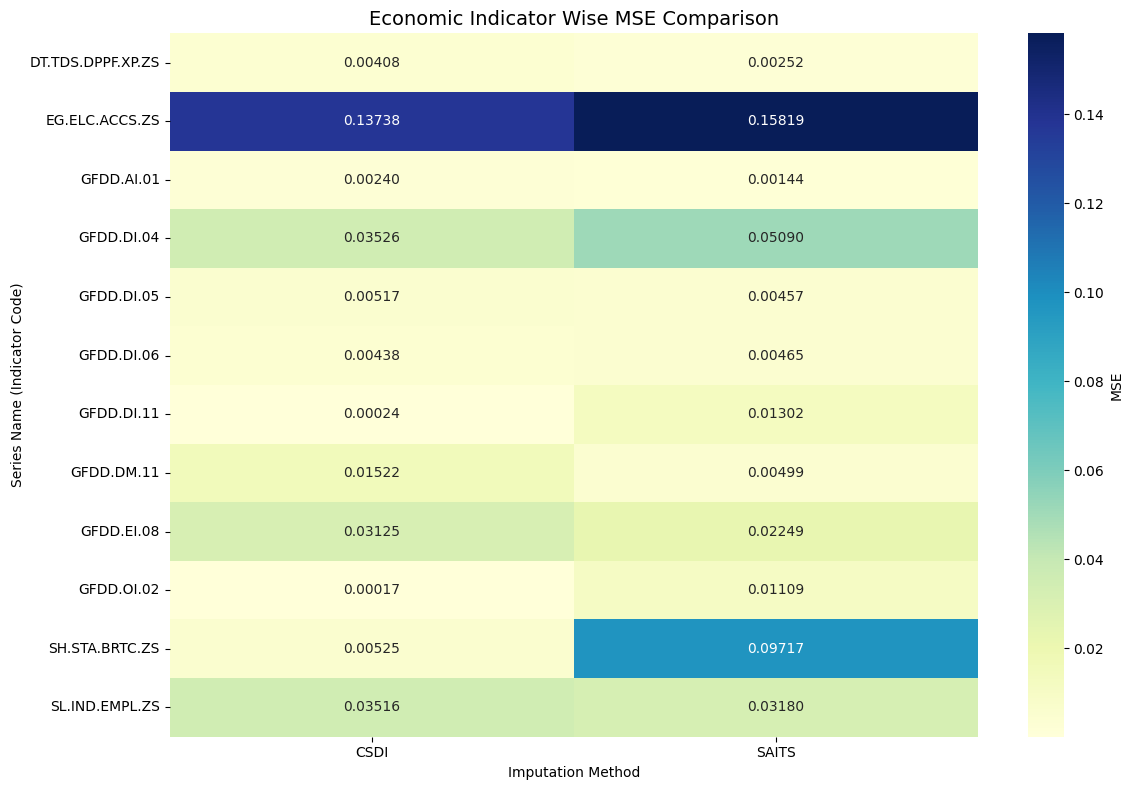

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 원본 데이터에서 실제 지표 이름(Series Code) 리스트 추출
# CSDI 파일을 기준으로 12개의 고유 지표 이름을 가져옵니다.
raw_df = pd.read_csv('/kaggle/input/imputated/WorldBank_CSDI_Final.csv')
real_names = raw_df['Series Code'].unique().tolist()

# 만약 이름이 12개가 안되거나 넘칠 경우를 대비해 슬라이싱
series_names = real_names[:12] 

all_series_results = []

for ds_name in ["CSDI", "SAITS"]:
    ds_key = f"my_{ds_name.lower()}_data"
    
    # 데이터 로드
    info = np.load(f'/kaggle/working/timeVAE-pytorch/data/{ds_key}.npz')
    gen_scaled = np.load(f'/kaggle/working/timeVAE-pytorch/outputs/gen_data/{ds_key}/vae_conv_{ds_key}_prior_samples.npz')['data']
    ori_scaled = info['data'][:len(gen_scaled)]
    
    # 12개 지표별 MSE 계산
    series_mses = []
    for i in range(12):
        mse = np.mean((ori_scaled[:, :, i] - gen_scaled[:, :, i])**2)
        series_mses.append(mse)
    
    all_series_results.append(series_mses)

# 2. 결과 데이터프레임 생성 (인덱스에 실제 이름 주입)
df_comparison = pd.DataFrame(
    all_series_results, 
    index=["CSDI", "SAITS"], 
    columns=series_names
).T

# 3. 수치 표 출력
print("📂 [지표별 실제 명칭 기준 MSE 상세 비교]")
display(df_comparison.style.highlight_min(axis=1, color='lightgreen'))

# 4. 히트맵 시각화 (지표 이름 포함)
plt.figure(figsize=(12, 8))
sns.heatmap(df_comparison, annot=True, fmt=".5f", cmap="YlGnBu", cbar_kws={'label': 'MSE'})
plt.title("Economic Indicator Wise MSE Comparison", fontsize=14)
plt.xlabel("Imputation Method")
plt.ylabel("Series Name (Indicator Code)")
plt.tight_layout()
plt.show()

In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

metrics_list = []

for ds_name in ["CSDI", "SAITS"]:
    ds_key = f"my_{ds_name.lower()}_data"
    info = np.load(f'/kaggle/working/timeVAE-pytorch/data/{ds_key}.npz')
    gen_scaled = np.load(f'/kaggle/working/timeVAE-pytorch/outputs/gen_data/{ds_key}/vae_conv_{ds_key}_prior_samples.npz')['data']
    ori_scaled = info['data'][:len(gen_scaled)]
    
    # 평탄화 (2D 변환)
    ori_2d = ori_scaled.reshape(-1, 12)
    gen_2d = gen_scaled.reshape(-1, 12)
    
    # 지표 계산
    mse = mean_squared_error(ori_2d, gen_2d)
    mae = mean_absolute_error(ori_2d, gen_2d)
    rmse = np.sqrt(mse)
    r2 = r2_score(ori_2d.flatten(), gen_2d.flatten()) # 전체 추세 결정계수

    metrics_list.append({
        "Model Combination": f"TimeVAE + {ds_name}",
        "Fidelity (MAE ↓)": mae,
        "Correlation (R2 ↑)": r2,
        "Utility (RMSE ↓)": rmse,
        "Accuracy (MSE ↓)": mse
    })

# 표 생성
final_table = pd.DataFrame(metrics_list)
print("\n📊 [최종 성능 비교 결과]")
display(final_table.style.highlight_min(axis=0, subset=["Fidelity (MAE ↓)", "Utility (RMSE ↓)", "Accuracy (MSE ↓)"], color='lightgreen')
                   .highlight_max(axis=0, subset=["Correlation (R2 ↑)"], color='lightgreen'))


📊 [최종 성능 비교 결과]


,Model Combination,Fidelity (MAE ↓),Correlation (R2 ↑),Utility (RMSE ↓),Accuracy (MSE ↓)
0,TimeVAE + CSDI,0.080034,0.811514,0.151645,0.022996
1,TimeVAE + SAITS,0.099972,0.703990,0.183219,0.033569


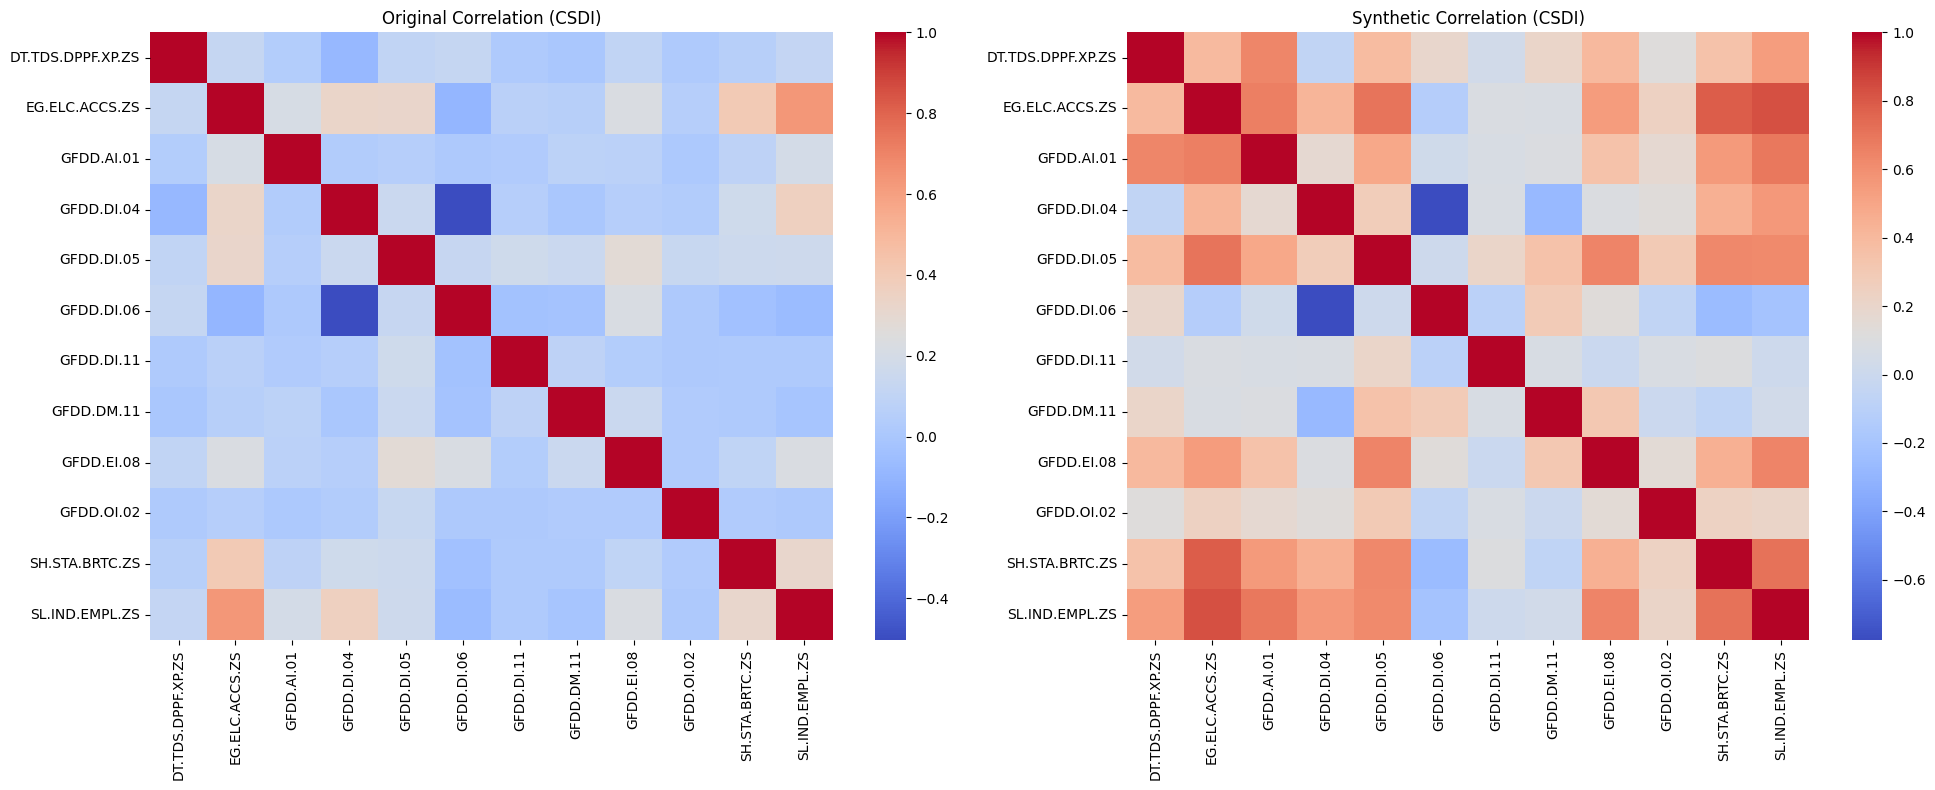

In [51]:
import seaborn as sns

def plot_correlation_comparison(ds_name):
    ds_key = f"my_{ds_name.lower()}_data"
    info = np.load(f'/kaggle/working/timeVAE-pytorch/data/{ds_key}.npz')
    gen_scaled = np.load(f'/kaggle/working/timeVAE-pytorch/outputs/gen_data/{ds_key}/vae_conv_{ds_key}_prior_samples.npz')['data']
    ori_scaled = info['data'][:len(gen_scaled)]

    # 2D로 변환 (Samples * Time, Features)
    ori_2d = ori_scaled.reshape(-1, 12)
    gen_2d = gen_scaled.reshape(-1, 12)

    # 상관관계 계산
    ori_corr = pd.DataFrame(ori_2d, columns=real_series_names).corr()
    gen_corr = pd.DataFrame(gen_2d, columns=real_series_names).corr()

    # 시각화
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
    sns.heatmap(ori_corr, annot=False, cmap='coolwarm', ax=ax1)
    ax1.set_title(f"Original Correlation ({ds_name})")
    
    sns.heatmap(gen_corr, annot=False, cmap='coolwarm', ax=ax2)
    ax2.set_title(f"Synthetic Correlation ({ds_name})")
    
    plt.tight_layout()
    plt.show()

# CSDI 결과 출력
plot_correlation_comparison("CSDI")